# Gradient Boosting
- **Gradient Boosting** é um algoritmo que utiliza decision trees de forma sequencial para tomar uma decisão, nesse caso classificar um registro (para problemas de classificação) ou estimar um valor (para problemas de regressão).
- Este algoritmo é uma implementação da técnica tradicional de Boosting, em que decision trees são usadas de forma sequencial para corrigir o erro da árvore anterior.
- Usando o Gradiente, a estratégia consiste em utilizar a subtração de $(y - \hat y)$, essa operação matemática é chamada de resíduo e ela será usada como gabarito da decision tree, ou seja, a tree tentará prever o valor do resíduo, o que implicitamente fará com que dados com resíduos parecidos sejam agrupados. Isso acontece por conta da utilização do Gradiente Negativo $(-\nabla)$ para otimização do erro, que nesse caso é o próprio $(y - \hat y)$.
- O valor inicial de $\hat y$ costuma ser a média dos valores de $y$ (para casos de regressão), após cada decision tree, o valor de $\hat y$ é atualizado através da equação: $$\hat y = \text{Média Inicial} + (LR \cdot Tree_1) + (LR \cdot Tree_2) + (LR \cdot Tree_N) $$
- Sendo $LR$ = Learning Rate e $Tree_N$ o valor final da árvore (a previsão do resíduo daquele nó folha).
- Gradient Boosting possui implementações otimizadas que utilizam de recursos como paralelismo para ganho de desempenho. Algumas libs disponíveis são: XGBoost, LightGBM e CatBoost
<img src="https://miro.medium.com/v2/1*OZPOQUKiaVmZOEMm_-8iYA.png" style="width: 600px;"/>

- **Utilizando o dataset California Housing (Regressão)**
    - https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html

In [6]:
# Importing pandas
import pandas as pd

In [7]:
# Importing california housing dataset
from sklearn.datasets import fetch_california_housing

In [8]:
# Fetching data
data = fetch_california_housing()

In [9]:
# Transformando em um DataFrame
california_housing = pd.DataFrame(data.data)
california_housing.columns = data.feature_names
california_housing['target'] = data.target
california_housing.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


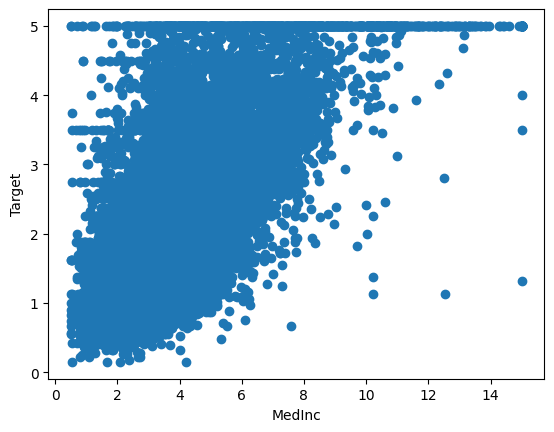

In [15]:
# Visualizing the data
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.scatter(california_housing['MedInc'], california_housing['target'])
ax.set_xlabel('MedInc')
ax.set_ylabel('Target')

plt.show()

In [16]:
# Separando X e y da base completa
X = california_housing.drop('target', axis=1)
y = california_housing.target

In [17]:
# Fazendo o train_test_split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [56]:
# Criando o classificador e fazendo o fit
from sklearn.ensemble import GradientBoostingRegressor

clf = GradientBoostingRegressor(random_state=42, learning_rate=0.1, n_estimators=500, min_samples_leaf=5, n_iter_no_change=10)
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_iter_no_change n_iter_no_change: int, default=None``n_iter_no_change`` is used to decide if early stopping will be usedto terminate training when validation score is not improving. Bydefault it is set to None to disable early stopping. If set to anumber, it will set aside ``validation_fraction`` size of the trainingdata as validation and terminate training when validation score is notimproving in all of the previous ``n_iter_no_change`` numbers ofiterations.Values must be in the range `[1, inf)`.See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_early_stopping.py`... versionadded:: 0.20",10
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int o

In [57]:
# Verificando o score
clf.score(X_train, y_train)

0.8547159414360737

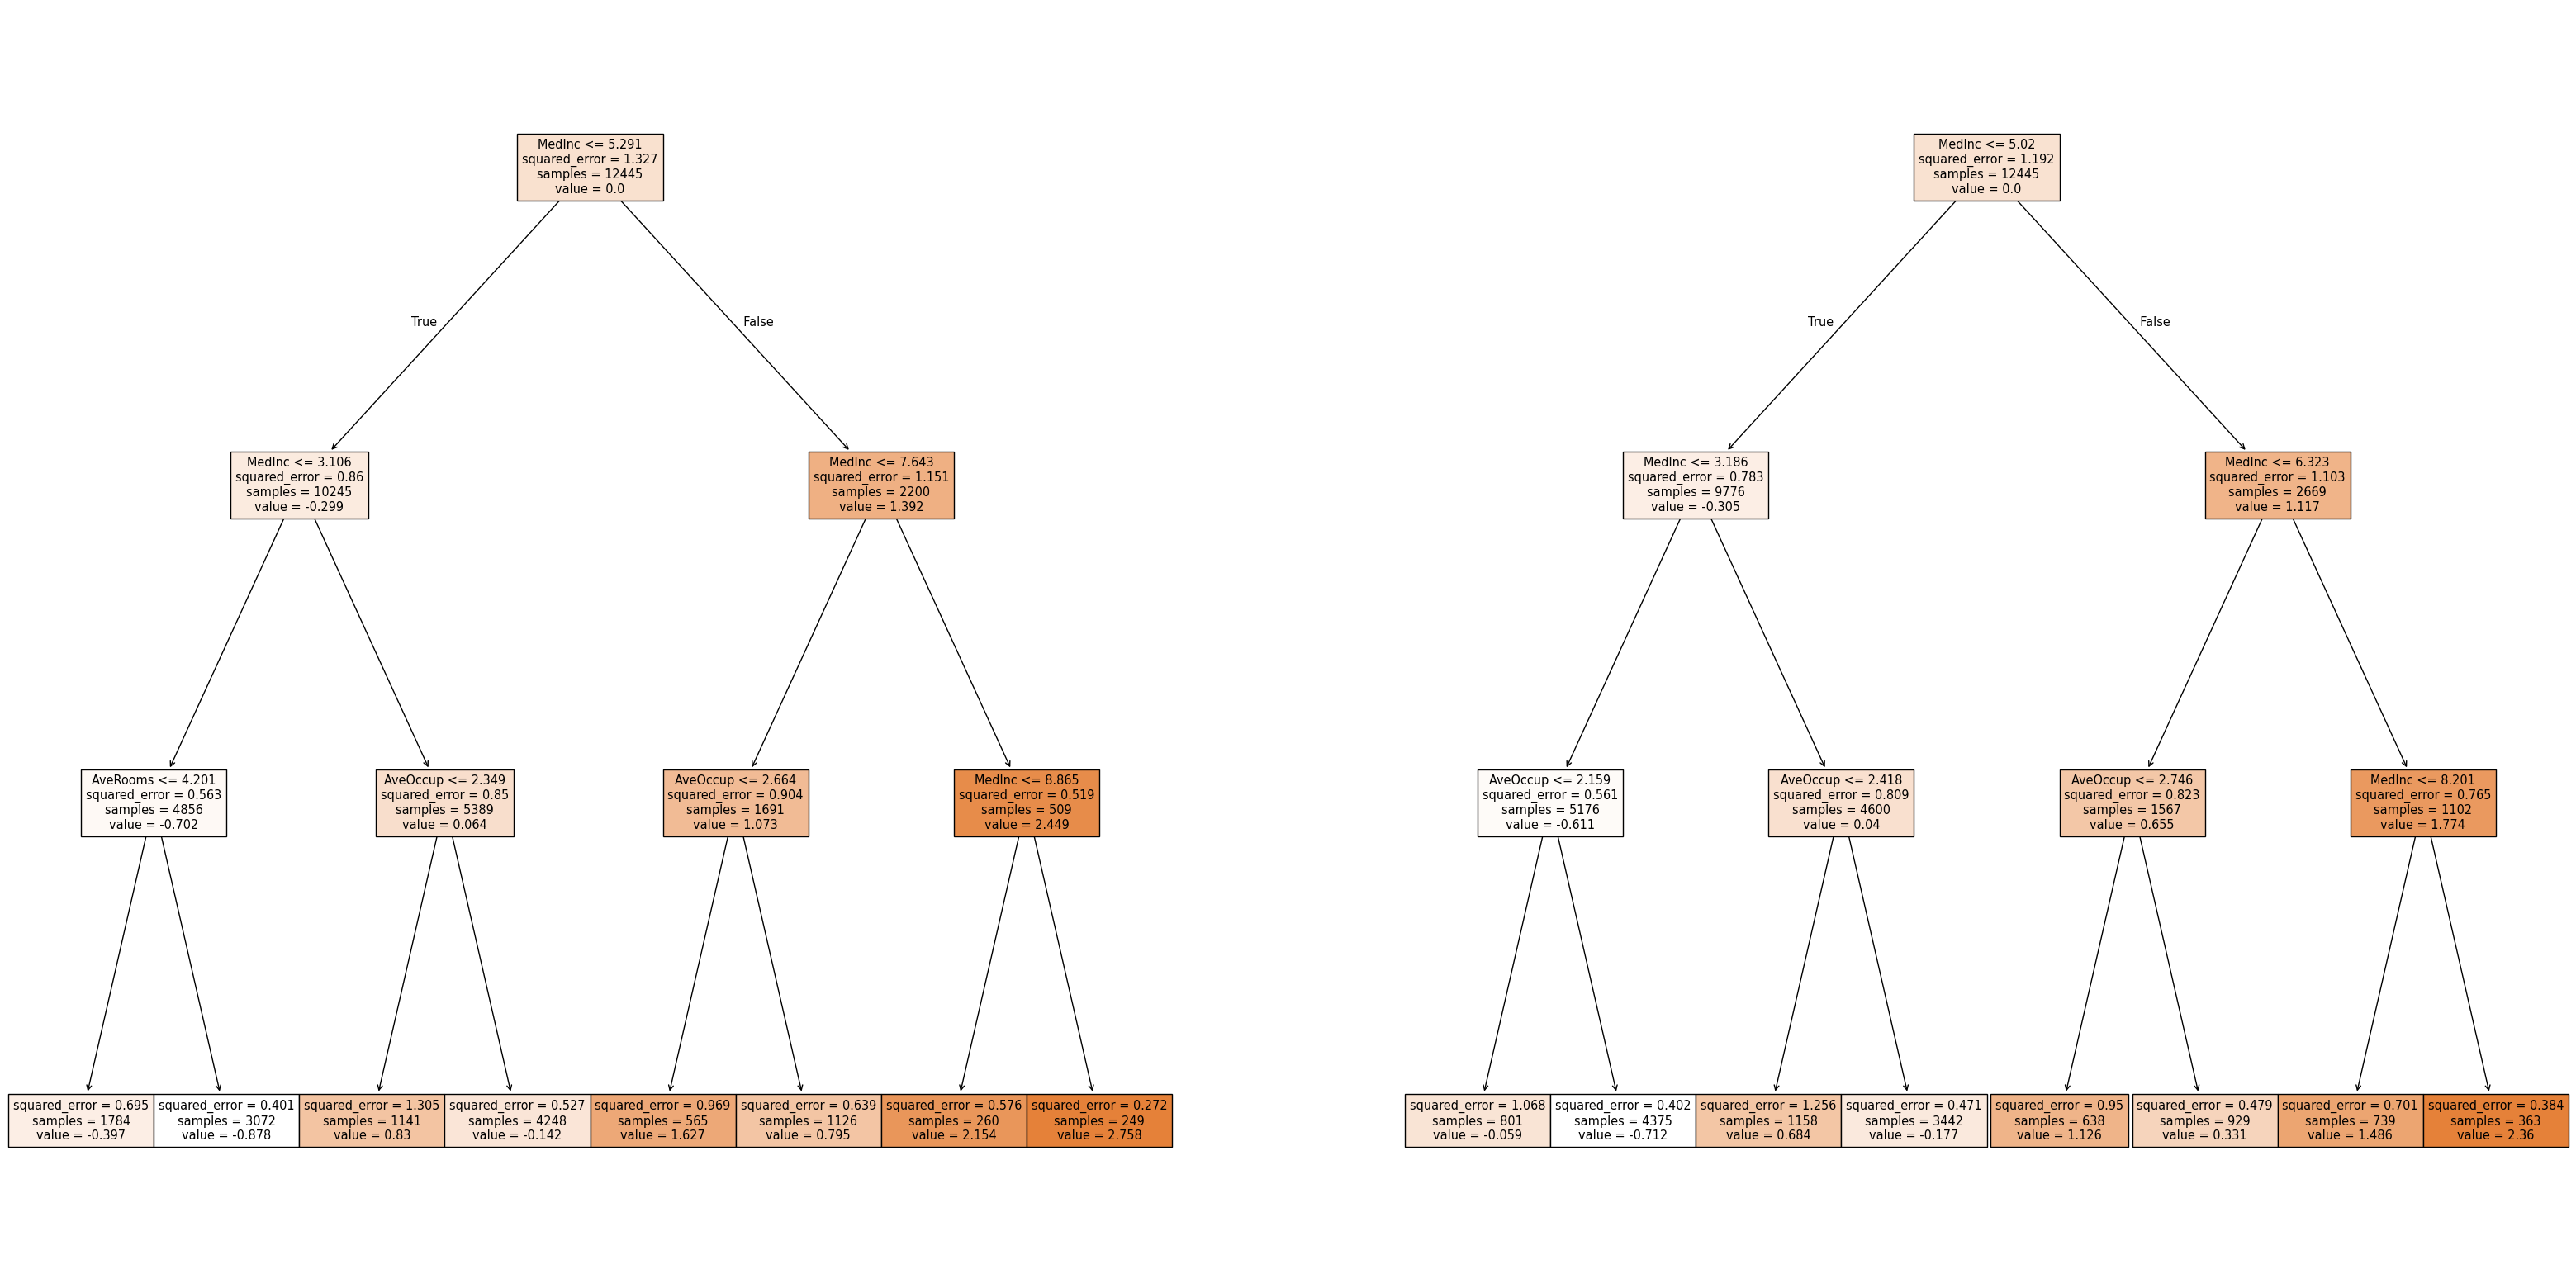

In [58]:
# Visualizing trees
import matplotlib.pyplot as plt
from sklearn import tree

n_forests = 2
fig, ax = plt.subplots(figsize=(40, 20), nrows=1, ncols=n_forests)

for i in range(n_forests):
    tree.plot_tree(clf.estimators_[i, 0], feature_names=X.columns, ax=ax[i], filled=True)

plt.show()

In [59]:
# Fazendo a previsão
y_pred = clf.predict(X_test)

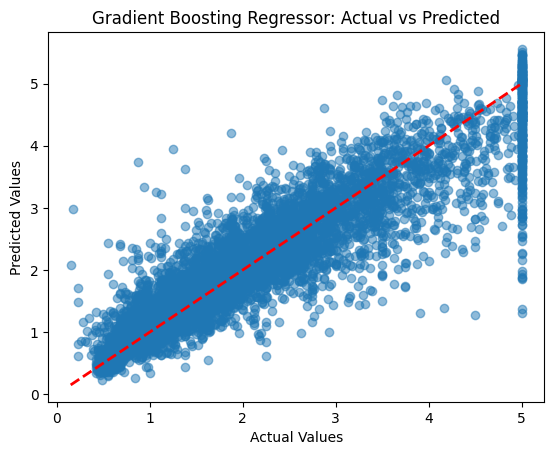

In [60]:
# Visualizing Predicted versus Real

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Gradient Boosting Regressor: Actual vs Predicted')
plt.show()

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluating the model
train_score = clf.score(X_train, y_train)
test_score = clf.score(X_test, y_test)

y_train_pred = clf.predict(X_train)

print("=== TRAIN SET ===")
print('MAE:', mean_absolute_error(y_train, y_train_pred))
print('MSE:', mean_squared_error(y_train, y_train_pred))
print('R² Score:', r2_score(y_train, y_train_pred))

print("\n=== TEST SET ===")
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print('R² Score:', r2_score(y_test, y_pred))

print("\n=== R2 SCORE ===")
print(f'Train R² Score: {train_score:.4f}')
print(f'Test R² Score: {test_score:.4f}')
print(f'Overfitting gap: {train_score - test_score:.4f}')

=== TRAIN SET ===
MAE: 0.3043423903045641
MSE: 0.193376864072666
R² Score: 0.8547159414360737

=== TEST SET ===
MAE: 0.33461006063038123
MSE: 0.24110411976109158
R² Score: 0.8190712887420202

=== R2 SCORE ===
Train R² Score: 0.8547
Test R² Score: 0.8191
Overfitting gap: 0.0356
